# ClickHouse Example — ML: Predict purchase-in-session from first N=5 events

## Objective
Train and compare models to predict whether a session will eventually contain a purchase.

- **Training table** (built in ClickHouse): `training_sessions_n5`
- **Target**: `has_purchase_in_session`

## Step 1/7 — Connect + load training data

**What this does**: Connects to ClickHouse and pulls a sample from `training_sessions_n5` into pandas.

**Why we do it**: ClickHouse is the feature store here; Python just trains models. We also print the positive rate to understand class imbalance.

**What to look for in the output**:
- Dataset shape looks reasonable
- Positive rate is a minority (often ~5–20%)
- The new user-history columns exist: `prior_sessions`, `prior_purchase_count`, `sec_since_last_session`, `hist_conversion_rate`

**If this fails**: Run `notebooks/clickhouse.API.ipynb` Step 6–7 first to rebuild `training_sessions_n5`.


In [ ]:
import time

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import sys
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    f1_score
)

sys.path.insert(0, str(Path("/app")))

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

from clickhouse_utils import get_client, ch_df, print_kv

print("Step 1/6: Connect + load training data")

client = get_client()
print_kv("ClickHouse version", client.execute("SELECT version()"))

q = """
SELECT
  user_session,
  user_id,

  -- prefix (first-N events) features
  start_hour,
  time_to_eventN_sec,
  prefix_events,
  prefix_views,
  prefix_carts,
  prefix_purchases,
  prefix_uniq_products,
  prefix_uniq_categories,
  prefix_uniq_brands,
  prefix_avg_price,
  prefix_max_price,
  prefix_cart_value_sum,

  -- user-history features (0 for first session)
  prior_sessions,
  prior_purchase_count,
  sec_since_last_session,
  hist_conversion_rate,

  -- label
  has_purchase_in_session
FROM training_sessions_n5
LIMIT 200000
"""

cols = [
    "user_session",
    "user_id",
    "start_hour",
    "time_to_eventN_sec",
    "prefix_events",
    "prefix_views",
    "prefix_carts",
    "prefix_purchases",
    "prefix_uniq_products",
    "prefix_uniq_categories",
    "prefix_uniq_brands",
    "prefix_avg_price",
    "prefix_max_price",
    "prefix_cart_value_sum",
    "prior_sessions",
    "prior_purchase_count",
    "sec_since_last_session",
    "hist_conversion_rate",
    "has_purchase_in_session",
]

df = pd.DataFrame(client.execute(q), columns=cols)
print_kv("Dataset shape", df.shape)
print_kv("Positive rate", float(df["has_purchase_in_session"].mean()))
print(df.head(3))


Step 1/6: Connect + load training data
ClickHouse version: [('26.3.9.8',)]
Dataset shape: (200000, 19)
Positive rate: 0.12947
                           user_session    user_id  start_hour  \
0  00000056-a206-40dd-b174-a072550fa38c  513782162           6   
1  00000f11-3c2e-4a22-b1b9-0a03276eb9cc  530035758           7   
2  000011ef-e9fc-4920-96cd-2534bda3cdc2  556327911          13   

   time_to_eventN_sec  prefix_events  prefix_views  prefix_carts  \
0                 226              5             5             0   
1                 197              5             5             0   
2                 616              5             5             0   

   prefix_purchases  prefix_uniq_products  prefix_uniq_categories  \
0                 0                     4                       2   
1                 0                     5                       3   
2                 0                     2                       1   

   prefix_uniq_brands  prefix_avg_price  prefix_max_price  

## Step 2/7 — Train/test split + baseline

**What this does**: Splits data into train/test sets and computes a simple baseline (majority-class accuracy).

**Why we do it**: Purchase is usually a minority class. A naive model can get high accuracy by predicting “no purchase” for everyone, so we want a baseline to compare against.

**What to look for in the output**:
- Similar positive rate in train vs overall (stratified split)
- Baseline accuracy is close to 1 − positive_rate

**Tip**: Because of class imbalance, focus more on ROC-AUC and Precision@K than raw accuracy.


In [ ]:
print("Step 2/7: Train/test split + baseline")

# Features (numeric only for simplicity)
feature_cols = [
    # prefix (early-session behavior)
    "start_hour",
    "time_to_eventN_sec",
    "prefix_events",
    "prefix_views",
    "prefix_carts",
    "prefix_purchases",
    "prefix_uniq_products",
    "prefix_uniq_categories",
    "prefix_uniq_brands",
    "prefix_avg_price",
    "prefix_max_price",
    "prefix_cart_value_sum",

    # user history (as-of session start; 0 for first session)
    "prior_sessions",
    "prior_purchase_count",
    "sec_since_last_session",
    "hist_conversion_rate",
]

X = df[feature_cols].fillna(0.0)
y = df["has_purchase_in_session"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print_kv("Train size", X_train.shape)
print_kv("Test size", X_test.shape)
print_kv("Train positive rate", float(y_train.mean()))
print_kv("Test positive rate", float(y_test.mean()))


baseline_acc = max(float((y_test == 0).mean()), float((y_test == 1).mean()))
print_kv("Baseline accuracy (majority class)", baseline_acc) # Reason: Majority of the class is '0'. So if the dumb model guesses '0' on every test set than it would have this accuracy.


Step 2/7: Train/test split + baseline
Train size: (150000, 16)
Test size: (50000, 16)
Train positive rate: 0.12947333333333333
Test positive rate: 0.12946
Baseline accuracy (majority class): 0.87054


## Step 3/7 — Logistic Regression (baseline ML model)

**What this does**: Trains a simple linear classifier with standardized features.

**Why we do it**: It’s a strong baseline that’s fast, interpretable, and often hard to beat on tabular data.

**What to look for in the output**:
- ROC-AUC is the main headline metric
- Precision/recall depend on the classification threshold (0.5 here)

**Interpretation**: If ROC-AUC is decent, your features (including user-history) carry signal even with a simple model.


In [ ]:
def eval_model(name: str, y_true, p_pred):
    y_hat = (p_pred >= 0.5).astype(int)
    return {
        "model": name,
        "roc_auc": float(roc_auc_score(y_true, p_pred)),
        "accuracy": float(accuracy_score(y_true, y_hat)),
        "precision": float(precision_score(y_true, y_hat, zero_division=0)),
        "recall": float(recall_score(y_true, y_hat, zero_division=0)),
    }

print("Step 3/7: Logistic Regression")

logreg = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)

t0 = time.perf_counter()
logreg.fit(X_train, y_train)
print_kv("LogReg train_time_sec", round(time.perf_counter() - t0, 3))

p_lr = logreg.predict_proba(X_test)[:, 1]
metrics_lr = eval_model("logreg", y_test, p_lr)


Step 3/7: Logistic Regression
LogReg train_time_sec: 1.025


## Step 4/7 — XGBoost (nonlinear model)

**What this does**: Trains a gradient-boosted tree model and evaluates it on the same test set.

**Why we do it**: Trees can capture nonlinear interactions (e.g., carts + price patterns) that linear models can miss.

**What to look for in the output**:
- ROC-AUC usually improves vs Logistic Regression (but not always)
- Confusion matrix reflects the 0.5 threshold choice

**Interpretation**: If XGBoost improves ROC-AUC, it’s often a better *ranker* for targeting high-intent sessions.


In [ ]:
print("Step 4/7: XGBoost")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
)

t0 = time.perf_counter()
xgb_model.fit(X_train, y_train)
print_kv("XGB train_time_sec", round(time.perf_counter() - t0, 3))

p_xgb = xgb_model.predict_proba(X_test)[:, 1]
metrics_xgb = eval_model("xgboost", y_test, p_xgb)


Step 4/7: XGBoost
XGB train_time_sec: 1.638


Top features by gain:
                   feature         gain
2             prefix_views  2347.805664
4         prefix_purchases  1828.149292
10   prefix_cart_value_sum   115.505562
14    hist_conversion_rate    94.896507
3             prefix_carts    83.527000
6   prefix_uniq_categories    42.552383
5     prefix_uniq_products    35.083561
12    prior_purchase_count    30.510435
0               start_hour    13.532544
9         prefix_max_price    12.545586
11          prior_sessions    10.316063
13  sec_since_last_session     8.545918
7       prefix_uniq_brands     8.492358
1       time_to_eventN_sec     7.842404
8         prefix_avg_price     6.893428


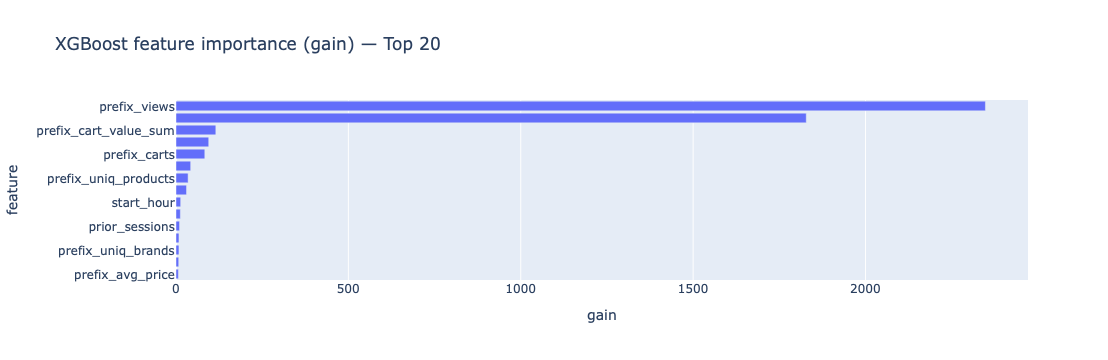

In [ ]:
# Feature importance (XGBoost) — importance_type="gain"
booster = xgb_model.get_booster()
score_gain = booster.get_score(importance_type="gain")  # keys like "f0", "f1", ...

# Map f0..fN to your column names
feature_map = {f"f{i}": col for i, col in enumerate(feature_cols)}

imp = (
    pd.DataFrame(
        [
            {"feature": feature_map.get(k, k), "gain": v}
            for k, v in score_gain.items()
        ]
    )
    .sort_values("gain", ascending=False)
)

print("Top features by gain:")
print(imp.head(15))

fig_imp = px.bar(
    imp.head(20).iloc[::-1],  # reverse for nicer horizontal ordering
    x="gain",
    y="feature",
    orientation="h",
    title="XGBoost feature importance (gain) — Top 20",
)
fig_imp.show()

## Step 5/7 — Visual evaluation (ROC + Precision@K)

**What this does**: Plots ROC curves (overall ranking quality) and Precision@K (how good the top K predictions are).

**Why we do it**: With class imbalance, accuracy can look “good” even for weak models. ROC-AUC and Precision@K are usually more informative for purchase prediction.

**What to look for in the output**:
- ROC curve above the diagonal; higher AUC is better
- Precision@K is meaningfully above the baseline purchase rate

**Interpretation**:
- ROC-AUC: how well the model ranks purchasers above non-purchasers
- Precision@K: if you target the top K sessions, what fraction are true purchasers


Step 5/7: Visual evaluation (ROC + Precision@K)


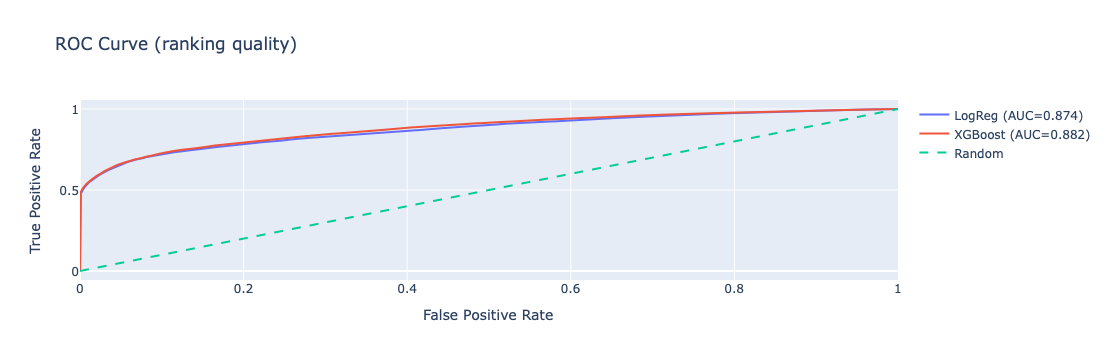

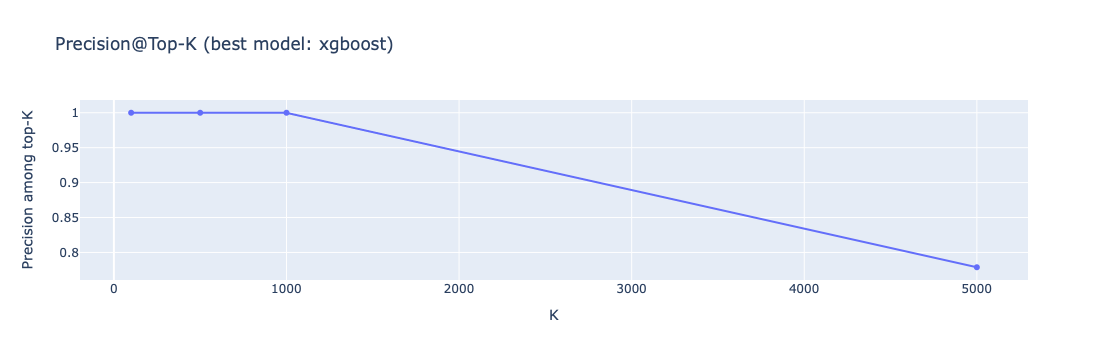

In [ ]:
print("Step 5/7: Visual evaluation (ROC + Precision@K)")

# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, p_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, p_xgb)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr_lr, y=tpr_lr, mode="lines", name=f"LogReg (AUC={metrics_lr['roc_auc']:.3f})"))
fig_roc.add_trace(go.Scatter(x=fpr_xgb, y=tpr_xgb, mode="lines", name=f"XGBoost (AUC={metrics_xgb['roc_auc']:.3f})"))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", name="Random", line=dict(dash="dash")))
fig_roc.update_layout(title="ROC Curve (ranking quality)", xaxis_title="False Positive Rate", yaxis_title="True Positive Rate")
fig_roc.show()

# Precision@K on best model
best_name, best_p = ("xgboost", p_xgb) if metrics_xgb["roc_auc"] >= metrics_lr["roc_auc"] else ("logreg", p_lr)
order = np.argsort(-best_p)
y_sorted = np.asarray(y_test)[order]

ks = [100, 500, 1000, 5000]
prec_at_k = [float(y_sorted[: min(k, len(y_sorted))].mean()) for k in ks]

fig_pk = px.line(x=ks, y=prec_at_k, markers=True, title=f"Precision@Top-K (best model: {best_name})")
fig_pk.update_layout(xaxis_title="K", yaxis_title="Precision among top-K")
fig_pk.show()


In [ ]:
threshold_results = []

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_threshold = (best_p >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1_score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

best_threshold = threshold_df.sort_values("f1_score", ascending=False).iloc[0]["threshold"]
print("Selected threshold:", best_threshold)

final_predictions = (best_p >= best_threshold).astype(int)


,threshold,accuracy,precision,recall,f1_score
0,0.1,0.87154,0.502638,0.735980,0.597329
1,0.2,0.91234,0.661365,0.661672,0.661518
2,0.3,0.92670,0.783751,0.599104,0.679100
3,0.4,0.93258,0.885821,0.550131,0.678738
4,0.5,0.93360,0.948762,0.514908,0.667535
5,0.6,0.93334,0.977494,0.496524,0.658539
6,0.7,0.93260,0.990826,0.483856,0.650197
7,0.8,0.93172,0.998696,0.473196,0.642138
8,0.9,0.93152,1.000000,0.471034,0.640412


Selected threshold: 0.3


In [ ]:
print(metrics_xgb)
print("Confusion matrix:\n", confusion_matrix(y_test, (p_xgb >= best_threshold).astype(int)))

print(metrics_lr)
print("Confusion matrix:\n", confusion_matrix(y_test, (p_lr >= best_threshold).astype(int)))

print("Model comparison:")
print(pd.DataFrame([metrics_lr, metrics_xgb]))

{'model': 'xgboost', 'roc_auc': 0.8822258790302991, 'accuracy': 0.9336, 'precision': 0.9487617421007686, 'recall': 0.5149080797157423}
Confusion matrix:
 [[42457  1070]
 [ 2595  3878]]
{'model': 'logreg', 'roc_auc': 0.873516945082193, 'accuracy': 0.90446, 'precision': 0.6194029850746269, 'recall': 0.6795921520160667}
Confusion matrix:
 [[30730 12797]
 [ 1120  5353]]
Model comparison:
     model   roc_auc  accuracy  precision    recall
0   logreg  0.873517   0.90446   0.619403  0.679592
1  xgboost  0.882226   0.93360   0.948762  0.514908
